# Notebook 06 — Modèle LightGBM

**Objectif de ce notebook :**
1. Charger `panel_pret_modelisation.parquet` et construire les **fenêtres d'entraînement
   glissantes/extensives** (identique aux notebooks 04 et 05, pour rester comparable)
2. Pour **chaque fenêtre**, entraîner un modèle **LightGBM** (gradient boosting sur arbres),
   plus flexible qu'un modèle linéaire, en utilisant l'**arrêt anticipé** (`early stopping`)
   sur la validation de cette fenêtre plutôt qu'une grande recherche d'hyperparamètres
3. Mettre bout à bout les prédictions de toutes les fenêtres, et évaluer avec le
   **même R²_oos à la GKX** que les notebooks 04 et 05, pour une comparaison équitable
4. Sauvegarder les prédictions de test (pour le notebook 07), le modèle de la dernière
   fenêtre et les résultats agrégés

**Pourquoi LightGBM plutôt qu'un réseau de neurones ?** LightGBM est optimisé pour la
mémoire (il construit les arbres par histogrammes plutôt qu'en gardant toutes les données en
mémoire en continu), tourne bien sur un PC modeste, et obtient de très bons résultats dans ce
type d'étude — souvent aussi bons que des réseaux de neurones, pour une fraction du coût de
calcul.

⚠️ **Installation requise** (une seule fois, dans un terminal) :
```
pip install lightgbm
```
Optionnel, pour la partie SHAP de la section 6bis (importance des variables) :
```
pip install shap
```
(le reste du notebook fonctionne normalement sans -- voir section 6bis pour le detail.)

⚠️ **Coût de calcul avec les fenêtres — le point le plus important de ce notebook.** La
grille ci-dessous teste `3 × 3 × 3 = 27` combinaisons **par fenêtre**, chacune avec jusqu'à
3000 arbres (avec arrêt anticipé). Avec un ré-entraînement annuel sur plusieurs décennies,
c'est de loin le notebook le plus lent des trois. Options si c'est trop lent sur ton PC,
du moins coûteux au plus radical :
1. Réduire la grille ci-dessous (ex: 2 valeurs par hyperparamètre au lieu de 3).
2. Augmenter `ANNEES_TEST_PAR_FENETRE` dans `config.py` (ex: 3 au lieu de 1 — ré-entraînement
   tous les 3 ans, donc 3 fois moins de fenêtres).
3. Réduire `n_estimators` et `stopping_rounds` ci-dessous.

## 0. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
import time
import sys
sys.path.append("..")  # pour pouvoir importer config.py, fenetres.py et journal.py, situes a la racine du projet
import config
import fenetres
import journal

config.assurer_dossiers()  # cree data/interim, data/processed, modeles/, outputs/ si absents

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## 1. Chargement des données et construction des fenêtres

In [ ]:
panel = pd.read_parquet(config.FICHIER_PANEL_MODELISATION)

caracteristiques = config.CARACTERISTIQUES_RETENUES
macro_predicteurs = config.MACRO_PREDICTEURS
predicteurs = config.PREDICTEURS
cible = config.CIBLE

liste_fenetres = fenetres.generer_fenetres(
    panel['annee_mois'].unique(),
    type_fenetre=config.TYPE_FENETRE,
    annees_train_initial=config.ANNEES_TRAIN_INITIAL,
    annees_validation=config.ANNEES_VALIDATION,
    annees_test_par_fenetre=config.ANNEES_TEST_PAR_FENETRE,
)

print(f"Mode : {config.TYPE_FENETRE}")
print(f"{len(liste_fenetres)} fenetres generees\n")
fenetres.resumer_fenetres(liste_fenetres)

## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Même métrique que les notebooks 04 et 05, indispensable pour comparer l'ensemble des
modèles équitablement au notebook 07 :

`R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`

Définie une seule fois dans `fenetres.py`, réutilisée telle quelle par les 3 modèles.

In [3]:
r2_oos = fenetres.r2_oos  # alias local, pour garder les memes noms de variables qu'avant

## 3. Entraînement avec arrêt anticipé, fenêtre par fenêtre

Plutôt qu'une grande grille comme au notebook 05 (Elastic Net), on profite d'une
fonctionnalité propre à LightGBM : on lui donne un budget large d'arbres, mais on
**surveille la performance sur la `validation` de la fenêtre en cours à chaque arbre
ajouté**, et on arrête dès que ça n'améliore plus depuis un certain nombre d'arbres
d'affilée. Ça évite le sur-apprentissage et limite le nombre d'hyperparamètres à tester
manuellement (`num_leaves`, `learning_rate` et `min_child_samples` ici) — répété pour
**chaque fenêtre**, comme pour l'Elastic Net au notebook 05.

⚠️ Comme pour les autres modèles du projet : c'est bien la `validation` de chaque fenêtre
qui sert à arrêter l'entraînement et à choisir les hyperparamètres, jamais son `test`.

On garde de côté, à chaque fenêtre, les prédictions sur `train`, `validation` et `test`
(comme aux notebooks 04 et 05) pour pouvoir les recoller à la section 4, sans avoir à
ré-entraîner une seconde fois (particulièrement important ici, vu le coût de LightGBM).

In [4]:
# Parametres SPECIFIQUES a LightGBM, dans config.py (voir sa docstring) :
# change-les LA-BAS, pas ici, pour qu'ils soient aussi correctement enregistres dans le
# journal des experiences (journal.py, notebook 08).
grille_num_leaves = config.GRILLE_NUM_LEAVES_LIGHTGBM
grille_learning_rate = config.GRILLE_LEARNING_RATE_LIGHTGBM
grille_min_child_samples = config.GRILLE_MIN_CHILD_SAMPLES_LIGHTGBM
n_estimators = config.N_ESTIMATORS_LIGHTGBM
stopping_rounds = config.STOPPING_ROUNDS_LIGHTGBM

debut_entrainement = time.perf_counter()  # chronometre le temps TOTAL, toutes fenetres confondues (voir section 7)

resultats_par_fenetre = []
predictions_toutes_fenetres = []
pool_train = {'y': [], 'pred': []}
pool_validation = {'y': [], 'pred': []}
importances_gain_par_fenetre = []   # voir section 6bis
importances_split_par_fenetre = []  # voir section 6bis
modele_final = None

for f in liste_fenetres:
    donnees = fenetres.preparer_fenetre(panel, f, predicteurs, macro_predicteurs, cible)

    # --- recherche d'hyperparametres (avec arret anticipe) sur la validation de CETTE fenetre ---
    recherche = []
    modeles_candidats = []
    for num_leaves in grille_num_leaves:
        for learning_rate in grille_learning_rate:
            for min_child_samples in grille_min_child_samples:
                modele = lgb.LGBMRegressor(
                    n_estimators=n_estimators,                # nombre max d'arbres, mais arret anticipe possible
                    num_leaves=num_leaves,
                    learning_rate=learning_rate,
                    min_child_samples=min_child_samples,
                    feature_fraction=0.7,
                    bagging_fraction=0.7,
                    bagging_freq=1,
                    reg_alpha=0.1,
                    reg_lambda=0.1,
                    importance_type='gain',
                    random_state=0,
                    verbose=-1,
                )
                modele.fit(
                    donnees['X_train'], donnees['y_train'],
                    eval_set=[(donnees['X_validation'], donnees['y_validation'])],
                    eval_metric='l2',
                    callbacks=[lgb.early_stopping(stopping_rounds=stopping_rounds, verbose=False)],  # arret anticipe si pas d'amelioration depuis stopping_rounds arbres
                )
                score = r2_oos(donnees['y_validation'], modele.predict(donnees['X_validation']))
                recherche.append({
                    'num_leaves': num_leaves, 'learning_rate': learning_rate,
                    'min_child_samples': min_child_samples,
                    'nb_arbres_utilises': modele.best_iteration_,
                    'r2_oos_validation': score,
                })
                modeles_candidats.append(modele)

    recherche = pd.DataFrame(recherche)
    meilleur_index = recherche['r2_oos_validation'].idxmax()
    modele = modeles_candidats[meilleur_index]
    meilleure_ligne = recherche.loc[meilleur_index]

    pred_train = modele.predict(donnees['X_train'])
    pred_validation = modele.predict(donnees['X_validation'])
    pred_test = modele.predict(donnees['X_test'])

    resultats_par_fenetre.append({
        'fenetre': f['numero'],
        'annee_test': f['annee_test'],
        'n_train': len(donnees['y_train']),
        'num_leaves': meilleure_ligne['num_leaves'],
        'learning_rate': meilleure_ligne['learning_rate'],
        'min_child_samples': meilleure_ligne['min_child_samples'],
        'nb_arbres_utilises': meilleure_ligne['nb_arbres_utilises'],
        'r2_oos_train': r2_oos(donnees['y_train'], pred_train),
        'r2_oos_validation': r2_oos(donnees['y_validation'], pred_validation),
        'r2_oos_test': r2_oos(donnees['y_test'], pred_test),
    })

    preds = donnees['id_test'].copy()
    preds[cible] = donnees['y_test'].values
    preds['prediction'] = pred_test
    preds['fenetre'] = f['numero']
    predictions_toutes_fenetres.append(preds)

    pool_train['y'].append(donnees['y_train'].values); pool_train['pred'].append(pred_train)
    pool_validation['y'].append(donnees['y_validation'].values); pool_validation['pred'].append(pred_validation)

    # Importance 'gain' et 'split' de CETTE fenetre (voir section 6bis) -- le gain est
    # normalise a 100 par fenetre pour rester comparable malgre des nombres d'arbres
    # differents d'une fenetre a l'autre (arret anticipe).
    gain_fenetre = modele.booster_.feature_importance(importance_type='gain').astype(float)
    if gain_fenetre.sum() > 0:
        gain_fenetre = gain_fenetre / gain_fenetre.sum() * 100
    split_fenetre = modele.booster_.feature_importance(importance_type='split').astype(float)
    importances_gain_par_fenetre.append(dict(zip(predicteurs, gain_fenetre)))
    importances_split_par_fenetre.append(dict(zip(predicteurs, split_fenetre)))

    modele_final = modele

    print(f"Fenetre {f['numero']:2d} (test {f['annee_test']:>9s}) : "
          f"num_leaves={int(meilleure_ligne['num_leaves']):>2d}, "
          f"lr={meilleure_ligne['learning_rate']:.3f}, "
          f"arbres={int(meilleure_ligne['nb_arbres_utilises']):>4d} | "
          f"R2_oos test = {resultats_par_fenetre[-1]['r2_oos_test']:.4f}")

duree_entrainement_secondes = time.perf_counter() - debut_entrainement

resultats_par_fenetre = pd.DataFrame(resultats_par_fenetre)
predictions_toutes_fenetres = pd.concat(predictions_toutes_fenetres, ignore_index=True)

print(f"\n{len(resultats_par_fenetre)} fenetres entrainees.")
print(f"Duree totale d'entrainement (toutes fenetres, recherche d'hyperparametres incluse) : "
      f"{duree_entrainement_secondes:.1f} s")

Fenetre  0 (test 2010-2013) : num_leaves=31, lr=0.010, arbres= 997 | R2_oos test = 0.0054


Fenetre  1 (test 2014-2017) : num_leaves=31, lr=0.005, arbres= 148 | R2_oos test = 0.0032


Fenetre  2 (test 2018-2021) : num_leaves=31, lr=0.005, arbres= 129 | R2_oos test = 0.0039

3 fenetres entrainees.
Duree totale d'entrainement (toutes fenetres, recherche d'hyperparametres incluse) : 1665.0 s


## 4. Évaluation hors-échantillon pooled (toutes les fenêtres mises bout à bout)

Même logique qu'aux notebooks 04 et 05 : on met toutes les prédictions bout à bout d'abord
(déjà fait dans la boucle ci-dessus, via `pool_train`, `pool_validation` et
`predictions_toutes_fenetres`), puis on calcule un seul R²_oos sur chaque série complète —
plutôt qu'une moyenne (biaisée) des R² par fenêtre.

In [5]:
r2_train = r2_oos(np.concatenate(pool_train['y']), np.concatenate(pool_train['pred']))
r2_validation = r2_oos(np.concatenate(pool_validation['y']), np.concatenate(pool_validation['pred']))
r2_test = r2_oos(predictions_toutes_fenetres[cible], predictions_toutes_fenetres['prediction'])

print(f"R2_oos train      (pooled, toutes fenetres) : {r2_train:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {r2_validation:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {r2_test:.4f}")

R2_oos train      (pooled, toutes fenetres) : 0.0113
R2_oos validation (pooled, toutes fenetres) : 0.0036
R2_oos test       (pooled, toutes fenetres) : 0.0041


## 5. Évolution du R²_oos de test et des hyperparamètres au fil des fenêtres

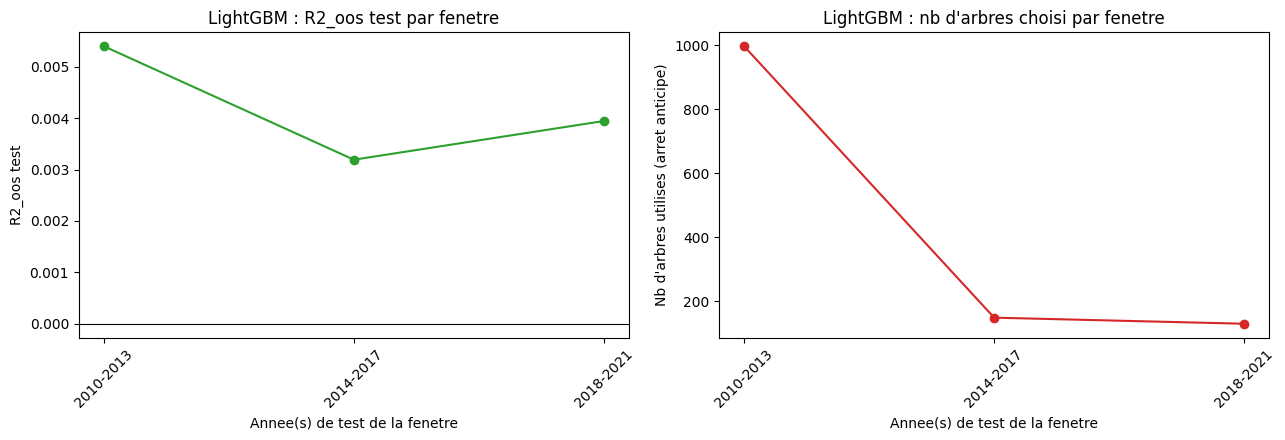

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['r2_oos_test'], marker='o', color='tab:green')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel("Annee(s) de test de la fenetre")
axes[0].set_ylabel("R2_oos test")
axes[0].set_title("LightGBM : R2_oos test par fenetre")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['nb_arbres_utilises'], marker='o', color='tab:red')
axes[1].set_xlabel("Annee(s) de test de la fenetre")
axes[1].set_ylabel("Nb d'arbres utilises (arret anticipe)")
axes[1].set_title("LightGBM : nb d'arbres choisi par fenetre")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Coup d'œil rapide à l'importance des variables (modèle de la dernière fenêtre)

Contrairement à l'Elastic Net (qui ramène des coefficients à 0), LightGBM donne un score
d'importance basé sur la contribution de chaque variable à la réduction de l'erreur
(`gain`) — utile pour voir quelles caractéristiques le modèle utilise le plus, même si
l'interprétation est moins directe qu'un coefficient linéaire. On regarde ici le modèle de
la **dernière fenêtre**, celui sauvegardé en `.joblib` à la section 7 -- un simple instantané, qui peut varier d'une fenêtre à l'autre. La section 6bis agrège cette importance sur **toutes** les fenêtres pour un diagnostic plus robuste, avec en prime une analyse SHAP du modèle final.

In [7]:
importances = pd.Series(modele_final.feature_importances_, index=predicteurs).sort_values(ascending=False)

print("Top 15 des variables les plus importantes :")
importances.head(15)

Top 15 des variables les plus importantes :


indmom      4357.895807
mom12m      2216.367623
maxret      1606.337649
mom1m       1136.427018
sp           935.968069
mom6m        713.487402
baspread     605.843571
agr          570.306121
mvel1        366.718959
ep           362.091231
cfp          341.393650
idiovol      338.736351
roaq         270.468937
dolvol       256.556590
gma          243.123760
dtype: float64

## 6bis. Importance des variables agrégée sur toutes les fenêtres (+ SHAP)

Comme pour l'Elastic Net (notebook 05, section 6bis), l'importance du modèle de la
**dernière fenêtre** seule peut être trompeuse : LightGBM peut redistribuer l'importance
différemment d'une fenêtre à l'autre (arbres différents, arrêt anticipé différent), même si
le pouvoir prédictif global reste stable. On regarde donc ici deux mesures natives de
LightGBM, moyennées (avec leur écart-type, pour juger la **stabilité**) sur toutes les
fenêtres entraînées en section 3 :

- **`gain`** : réduction totale de l'erreur apportée par les splits utilisant cette
  variable — la mesure la plus informative économiquement (proche d'un "pouvoir
  explicatif"), normalisée à 100 par fenêtre pour rester comparable malgré des nombres
  d'arbres différents.
- **`split`** : nombre de fois que la variable est utilisée pour couper un nœud, toutes
  profondeurs confondues — mesure la fréquence d'usage plutôt que l'impact, utile pour
  repérer des variables souvent utilisées mais pour des gains marginaux (splits profonds).

On complète avec une analyse **SHAP** (SHapley Additive exPlanations, Lundberg & Lee, 2017)
du modèle de la dernière fenêtre : contrairement à `gain`/`split` (agrégés, sans direction),
SHAP donne une contribution **signée** par variable et par observation — utile pour voir
non seulement *quelles* variables comptent, mais aussi *dans quel sens* (ex : un rang de
momentum élevé pousse-t-il la prédiction vers le haut ou vers le bas ?).

⚠️ **Installation requise pour la partie SHAP** (une seule fois) : `pip install shap`. Le
reste de cette section (gain/split agrégés) ne dépend d'aucun package supplémentaire ; si
`shap` n'est pas installé, la cellule SHAP l'indique et s'arrête proprement sans faire
planter le reste du notebook.

In [ ]:
gain_par_fenetre_df = pd.DataFrame(importances_gain_par_fenetre, index=resultats_par_fenetre['fenetre'])
split_par_fenetre_df = pd.DataFrame(importances_split_par_fenetre, index=resultats_par_fenetre['fenetre'])

importance_agregee = pd.DataFrame({
    'gain_moyen_pct': gain_par_fenetre_df.mean(),
    'gain_ecart_type_pct': gain_par_fenetre_df.std(),
    'split_moyen': split_par_fenetre_df.mean(),
    'split_ecart_type': split_par_fenetre_df.std(),
    'jamais_utilisee_pct_fenetres': (split_par_fenetre_df == 0).mean() * 100,
}).sort_values('gain_moyen_pct', ascending=False)

print(f"Importance agregee sur {len(gain_par_fenetre_df)} fenetres.")
print(f"{(importance_agregee['jamais_utilisee_pct_fenetres'] == 100).sum()} / {len(importance_agregee)} "
      "predicteurs ne sont utilises dans AUCUN arbre d'aucune fenetre.")
print()
print("Top 20 des predicteurs par gain moyen (avec leur variabilite d'une fenetre a l'autre) :")
importance_agregee.head(20).round(3)

In [ ]:
import matplotlib.pyplot as plt

top20_imp = importance_agregee.head(20).sort_values('gain_moyen_pct')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_imp.index, top20_imp['gain_moyen_pct'],
        xerr=top20_imp['gain_ecart_type_pct'], color='tab:green', ecolor='dimgray', capsize=3)
ax.set_xlabel("Gain moyen (%, normalise par fenetre) ± ecart-type entre fenetres")
ax.set_title("Top 20 des variables LightGBM par importance 'gain'\n(moyenne et stabilite sur toutes les fenetres)")
plt.tight_layout()
plt.show()

importance_agregee.to_parquet(config.FICHIER_IMPORTANCE_LIGHTGBM)
print("Tableau d'importance sauvegarde :", config.FICHIER_IMPORTANCE_LIGHTGBM)

In [ ]:
try:
    import shap

    # Echantillon du TEST de la derniere fenetre (SHAP est couteux ligne par ligne -- un
    # echantillon suffit largement pour un diagnostic visuel, pas besoin de tout le test).
    derniere_fenetre = liste_fenetres[-1]
    donnees_derniere_fenetre = fenetres.preparer_fenetre(panel, derniere_fenetre, predicteurs, macro_predicteurs, cible)
    X_test_derniere = donnees_derniere_fenetre['X_test']
    taille_echantillon = min(2000, len(X_test_derniere))
    X_echantillon = X_test_derniere.sample(n=taille_echantillon, random_state=0)

    explainer = shap.TreeExplainer(modele_final)
    valeurs_shap = explainer.shap_values(X_echantillon)

    shap.summary_plot(valeurs_shap, X_echantillon, max_display=20, show=False)
    fig = plt.gcf()
    fig.set_size_inches(8, 7)
    plt.title(f"SHAP -- modele de la derniere fenetre (echantillon test, n={taille_echantillon})")
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_DIR / "shap_lightgbm_derniere_fenetre.png", dpi=150)
    plt.show()
    print("Graphique SHAP sauvegarde :", config.OUTPUTS_DIR / "shap_lightgbm_derniere_fenetre.png")

except ImportError:
    print("Le package 'shap' n'est pas installe -- section ignoree (le reste du notebook n'est pas affecte).")
    print("Installe-le avec : pip install shap")

## 7. Sauvegarde du modèle, des prédictions et des résultats

In [8]:
joblib.dump(modele_final, config.FICHIER_MODELE_LIGHTGBM)
print("Modele final (derniere fenetre) sauvegarde :", config.FICHIER_MODELE_LIGHTGBM)

Modele final (derniere fenetre) sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V9 gkx_project automatisation pipeline\modeles\lightgbm.joblib


In [9]:
predictions_toutes_fenetres.to_parquet(config.FICHIER_PREDICTIONS_LIGHTGBM, index=False)
print("Predictions (toutes fenetres) sauvegardees :", config.FICHIER_PREDICTIONS_LIGHTGBM)
predictions_toutes_fenetres.head()

Predictions (toutes fenetres) sauvegardees : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V9 gkx_project automatisation pipeline\outputs\predictions_lightgbm.parquet


,permno,annee_mois,excess_return,prediction,fenetre
0,10001,201001,-0.018932,0.013268,0
1,10002,201001,0.365854,-0.025920,0
2,10025,201001,-0.088036,0.018754,0
3,10026,201001,0.046296,0.003985,0
4,10032,201001,0.194171,0.008006,0


In [ ]:
# Parametres SPECIFIQUES a LightGBM (definis ici, AVANT resultats_finaux, pour etre
# reutilises tels quels a la fois pour la cle_experience ci-dessous et pour
# journal.enregistrer_experience en section 8 -- garantit la meme cle aux deux endroits).
params_specifiques = {
    'grille_num_leaves': grille_num_leaves,
    'grille_learning_rate': grille_learning_rate,
    'grille_min_child_samples': grille_min_child_samples,
    'n_estimators': n_estimators,
    'stopping_rounds': stopping_rounds,
}

# Cle d'unicite de CETTE experience -- voir notebook 04, section 7, pour le detail complet
# de ce que ca permet de relier au notebook 07 (portefeuilles) et au notebook 08 (Sharpe...).
cle_experience = journal.cle_experience_actuelle('LightGBM', params_specifiques)

resultats_finaux = pd.DataFrame([{
    'modele': 'LightGBM',
    'type_fenetre': config.TYPE_FENETRE,
    'n_fenetres': len(liste_fenetres),
    'r2_oos_train': r2_train,
    'r2_oos_validation': r2_validation,
    'r2_oos_test': r2_test,
    'cle_experience': cle_experience,
}])

resultats_finaux.to_parquet(config.FICHIER_RESULTATS_LIGHTGBM, index=False)
resultats_par_fenetre.to_parquet(config.FICHIER_RESULTATS_LIGHTGBM_PAR_FENETRE, index=False)

print("Resultats pooled sauvegardes      :", config.FICHIER_RESULTATS_LIGHTGBM)
print("Resultats par fenetre sauvegardes :", config.FICHIER_RESULTATS_LIGHTGBM_PAR_FENETRE)
resultats_finaux

## 8. Enregistrement dans le journal des experiences (notebook 08)

Comme pour les deux autres modèles, on ajoute une ligne au **journal des expériences**
(`outputs/journal_experiences.parquet`, jamais écrasé, voir `journal.py`) : les paramètres
**spécifiques** sont ici `grille_num_leaves`, `grille_learning_rate`,
`grille_min_child_samples`, `n_estimators` et `stopping_rounds` (propres à LightGBM, déjà
rassemblés dans `params_specifiques` en section 7, réutilisé tel quel ci-dessous).

⚠️ **A noter** : `resultats_finaux` (section 7) inclut une colonne
`cle_experience` (voir `journal.cle_experience_actuelle`), reprise par le notebook 07 pour
relier le Sharpe/Sortino/... de **ce** lancement à la bonne ligne du tableau du notebook 08.

In [ ]:
journal.enregistrer_experience(
    modele='LightGBM',
    params_specifiques=params_specifiques,  # meme variable qu'en section 7 (garantit la
                                             # MEME cle_experience que resultats_finaux)
    resultats={
        'n_fenetres': len(liste_fenetres),
        'r2_oos_train': r2_train,
        'r2_oos_validation': r2_validation,
        'r2_oos_test': r2_test,
    },
    duree_entrainement_secondes=duree_entrainement_secondes,
)

## 9. Résumé et prochaines étapes

- Hyperparamètres (`num_leaves`, `learning_rate`, `min_child_samples`) choisis par petite
  grille, avec arrêt anticipé sur la `validation` de **chaque fenêtre** pour fixer
  automatiquement le nombre d'arbres.
- Même métrique (`R²_oos` à la GKX, pooled sur toutes les fenêtres) et même logique de
  fenêtres que les notebooks 04 et 05, pour une comparaison équitable.
- Modèle de la dernière fenêtre sauvegardé dans `modeles/lightgbm.joblib`.
- Prédictions pooled sauvegardées dans `outputs/predictions_lightgbm.parquet`.
- Résultats (pooled + par fenêtre, avec les hyperparamètres choisis à chaque fois)
  sauvegardés dans `outputs/resultats_lightgbm*.parquet`.
- **Importance des variables (section 6bis)** : gain et split moyennés (avec écart-type)
  sur **toutes** les fenêtres, plus une analyse SHAP signée du modèle final — sauvegardée
  dans `outputs/importance_lightgbm.parquet` (+ `outputs/shap_lightgbm_derniere_fenetre.png`
  si `shap` est installé).
- Expérience ajoutée à `outputs/journal_experiences.parquet` (sans doublon), regroupée avec les
  autres lancements utilisant la même grille d'hyperparamètres -- voir le notebook 08.

**Prochaine étape (Notebook 07) :** charger les résultats et prédictions déjà sauvegardés
des 3 modèles (régression linéaire, Elastic Net, LightGBM), les comparer côte à côte, et
construire des portefeuilles long-short pour évaluer leur valeur économique, pas seulement
statistique.